# Análisis de Producción de Hidrocarburos en Argentina (2007-2025)

## ¿Qué analiza este documento?

Este análisis examina la producción de petróleo y gas en Argentina durante el período **2007-2025**. El objetivo es entender:
- **Cómo ha evolucionado** la producción total de hidrocarburos en el país
- **Qué cuencas** son las más importantes y cómo han cambiado a lo largo del tiempo
- **El crecimiento** de la producción no convencional (shale y tight)
- **La productividad** de los pozos según su antigüedad

## ¿Qué son las cuencas?

Las **cuencas** son regiones geográficas donde se extraen hidrocarburos. Argentina tiene cinco cuencas principales:
- **Cuenca Neuquina**: La más importante, ubicada en Neuquén, Río Negro y Mendoza
- **Golfo San Jorge**: En Chubut y Santa Cruz
- **Cuenca Austral**: En Santa Cruz y Tierra del Fuego
- **Noroeste**: En Salta, Jujuy y otras provincias del norte
- **Cuyana**: En Mendoza y San Juan

## ¿Qué significan los datos?

- **Producción total**: Cantidad total de petróleo y gas producido cada mes
- **Producción no convencional**: Petróleo y gas extraído mediante técnicas especiales (fracking) de formaciones como Vaca Muerta
- **Shale y Tight**: Tipos específicos de recursos no convencionales
- **Productividad por pozo**: Cuánto produce cada pozo según su antigüedad

In [41]:
# Importación de librerías
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Filtrar solo warnings específicos (statsmodels puede emitir ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")

# Configuración de rutas: DATA_DIR o ./data relativo al proyecto
PROJECT_ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("DATA_DIR", PROJECT_ROOT / "data"))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Configuración de gráficos
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [42]:
# Carga de datos (rutas configurables: colocar CSVs en data/ o definir DATA_DIR)
try:
    from hidrocarburos_utils import cargar_serie_historica
    df = cargar_serie_historica(DATA_DIR)
except FileNotFoundError as e:
    print(f"Error al cargar datos: {e}")
    raise

# Filtrar período 2007-2025
df_filtrado = df.loc['2007-01':'2025-10'].copy()

# Información básica del dataset
print("Información del dataset (PERÍODO 2007-2025):")
print(f"Período original: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
print(f"Período filtrado: {df_filtrado.index.min().strftime('%Y-%m')} a {df_filtrado.index.max().strftime('%Y-%m')}")
print(f"Registros originales: {len(df)}")
print(f"Registros filtrados: {len(df_filtrado)}")
print(f"Registros excluidos (2006): {len(df) - len(df_filtrado)}")
print(f"Variables: {list(df_filtrado.columns)}")

display(df_filtrado.head())

Información del dataset (PERÍODO 2007-2025):
Período original: 2006-01 a 2025-10
Período filtrado: 2007-01 a 2025-10
Registros originales: 238
Registros filtrados: 226
Registros excluidos (2006): 12
Variables: ['cuenca_austral', 'cuenca_gsj', 'cuenca_neuquina', 'cuenca_noroeste', 'cuenca_cuyana', 'total', 'total_diario', 'shale', 'tight', 'part_no_conv', 'kbbl_diario']


,cuenca_austral,cuenca_gsj,cuenca_neuquina,cuenca_noroeste,cuenca_cuyana,total,total_diario,shale,tight,part_no_conv,kbbl_diario
indice_tiempo,,,,,,,,,,,
2007-01-01,144024.5465,1.386611e+06,1.338568e+06,72239.5762,181375.5653,3.122819e+06,100736.0882,333.184,908.9389,0.0398,633.6110
2007-02-01,125284.9471,1.276211e+06,1.213168e+06,65342.1388,165189.0469,2.845194e+06,101614.0867,287.778,722.8905,0.0355,639.1334
2007-03-01,150735.0074,1.410711e+06,1.349291e+06,67591.8186,185643.7243,3.163972e+06,102063.6232,268.440,726.1606,0.0314,641.9609
2007-04-01,145248.6771,1.368792e+06,1.324769e+06,67627.9475,178034.8457,3.084472e+06,102815.7438,309.350,662.4024,0.0315,646.6916
2007-05-01,151013.5611,1.400821e+06,1.368339e+06,65522.0243,177173.6462,3.162869e+06,102028.0402,229.867,790.5490,0.0323,641.7371


## Estadísticas Descriptivas

Antes de analizar tendencias y patrones, es importante entender las características básicas de los datos:

### ¿Qué información proporcionan las estadísticas?

- **Promedio**: Valor típico de producción
- **Mínimo y Máximo**: Los extremos del período analizado
- **Desviación estándar**: Qué tan variable es la producción (valores altos = más variabilidad)
- **Cuartiles**: Valores que dividen los datos en cuatro partes iguales

Estas estadísticas nos dan una **fotografía general** de la producción antes de profundizar en los detalles.

In [43]:
# Estadísticas descriptivas
print("Estadísticas descriptivas (PERÍODO 2007-2025):")
display(df_filtrado.describe())

# Verificación de valores nulos
print("Valores nulos por columna:")
print(df_filtrado.isnull().sum())

Estadísticas descriptivas (PERÍODO 2007-2025):


,cuenca_austral,cuenca_gsj,cuenca_neuquina,cuenca_noroeste,cuenca_cuyana,total,total_diario,shale,tight,part_no_conv,kbbl_diario
count,226.000000,2.260000e+02,2.260000e+02,226.000000,226.000000,2.260000e+02,226.000000,2.260000e+02,226.000000,226.000000,226.000000
mean,101956.775387,1.153815e+06,1.365353e+06,38413.737613,126507.262609,2.786053e+06,91531.297327,4.843318e+05,20478.604187,16.690509,575.714558
std,31561.729144,1.598132e+05,4.732376e+05,17065.339235,31792.898398,3.790275e+05,12186.331360,6.812353e+05,13132.208309,20.005411,76.649721
min,47656.643000,7.956543e+05,8.907406e+05,13027.969900,67319.489600,2.187848e+06,72657.134600,1.174030e+02,662.402400,0.031400,456.999600
25%,76286.741500,9.993417e+05,1.076785e+06,23964.503700,94911.295925,2.511304e+06,82528.711250,9.696969e+03,7406.471675,0.589050,519.090025
50%,105574.433500,1.169762e+06,1.184813e+06,35975.335950,131478.831000,2.686294e+06,87669.029900,1.362230e+05,22888.587950,6.758300,551.421600
75%,126650.757000,1.292441e+06,1.356270e+06,49158.914675,153025.555000,3.008986e+06,99044.236325,6.456230e+05,30078.256650,28.299000,622.969475
max,160363.723100,1.423012e+06,3.222377e+06,73932.390100,185643.724300,4.231155e+06,136488.877200,2.801581e+06,46317.764900,66.698400,858.489200


Valores nulos por columna:
cuenca_austral     0
cuenca_gsj         0
cuenca_neuquina    0
cuenca_noroeste    0
cuenca_cuyana      0
total              0
total_diario       0
shale              0
tight              0
part_no_conv       0
kbbl_diario        0
dtype: int64


## Evolución de la Producción Total (2007-2025)

En esta sección observamos cómo ha cambiado la producción total de hidrocarburos en Argentina a lo largo del tiempo. Los gráficos muestran:
- **Tendencias**: Si la producción está aumentando, disminuyendo o se mantiene estable
- **Variaciones mensuales**: Cómo fluctúa la producción mes a mes
- **Promedios diarios**: Para facilitar la comparación entre meses de diferente duración

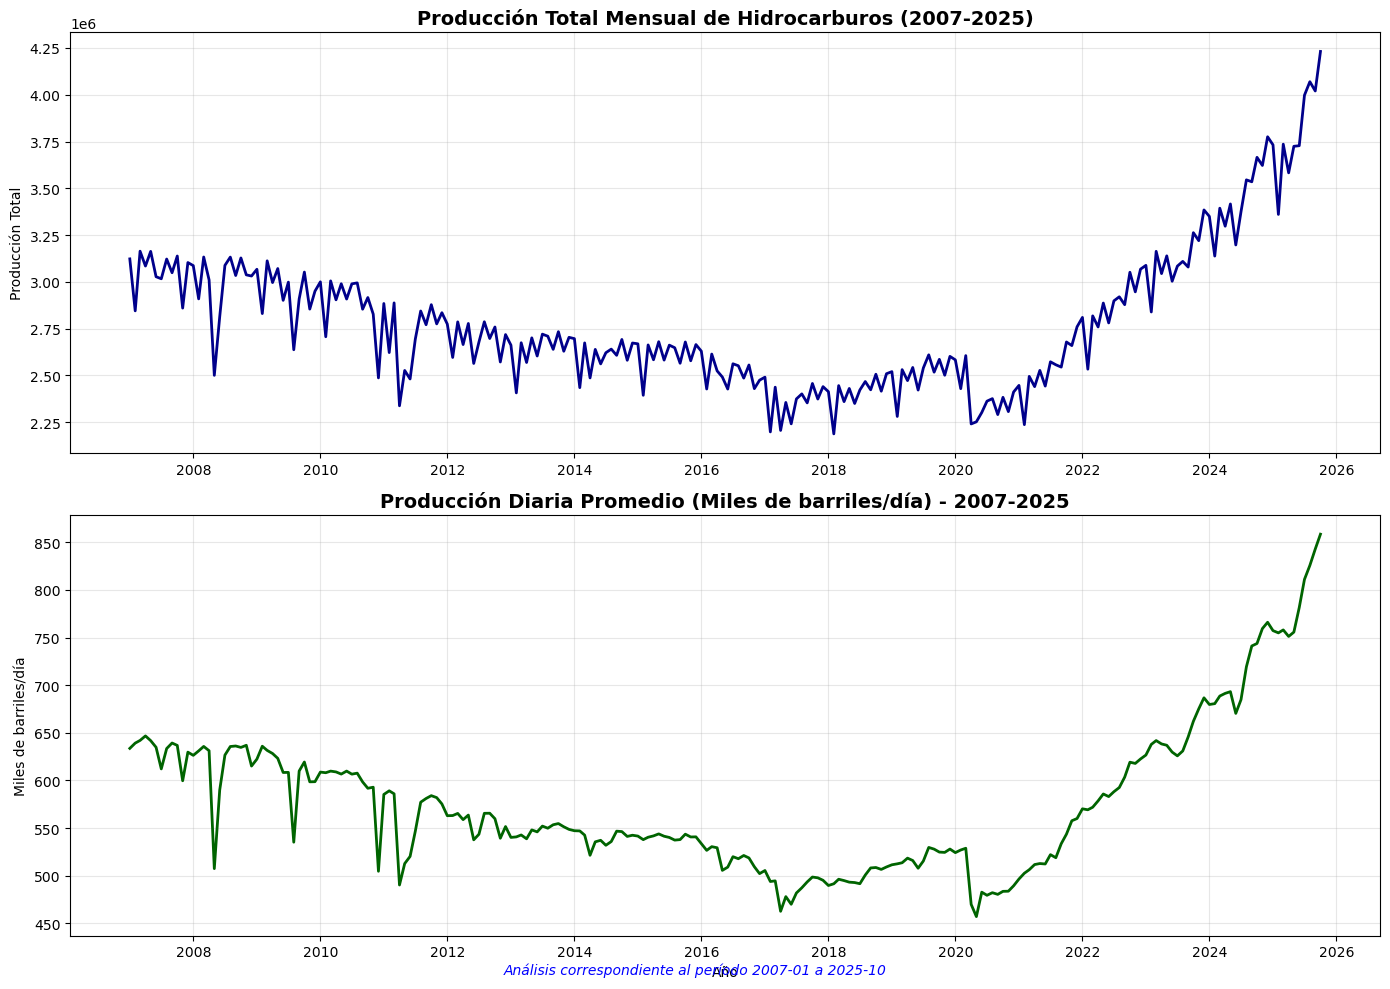

In [44]:
# Gráfico de producción total a lo largo del tiempo (2007-2025)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Producción total mensual
axes[0].plot(df_filtrado.index, df_filtrado["total"], linewidth=2, color="darkblue")
axes[0].set_title("Producción Total Mensual de Hidrocarburos (2007-2025)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Producción Total")
axes[0].grid(True, alpha=0.3)

# Producción diaria promedio
axes[1].plot(df_filtrado.index, df_filtrado["kbbl_diario"], linewidth=2, color="darkgreen")
axes[1].set_title("Producción Diaria Promedio (Miles de barriles/día) - 2007-2025", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Miles de barriles/día")
axes[1].set_xlabel("Año")
axes[1].grid(True, alpha=0.3)

# Añadir nota sobre período
fig.text(0.5, 0.02, 'Análisis correspondiente al período 2007-01 a 2025-10', 
         ha='center', fontsize=10, style='italic', color='blue')

plt.tight_layout()
plt.show()

## Producción por Cuenca (2007-2025)

Cada cuenca tiene características diferentes y contribuye de manera distinta a la producción nacional. En esta sección veremos:
- **Cuál es la cuenca más importante** en términos de producción
- **Cómo ha cambiado** la participación de cada cuenca a lo largo del tiempo
- **Si alguna cuenca está creciendo** más rápido que otras

Esto ayuda a entender la **distribución geográfica** de la producción y dónde se concentran los recursos.

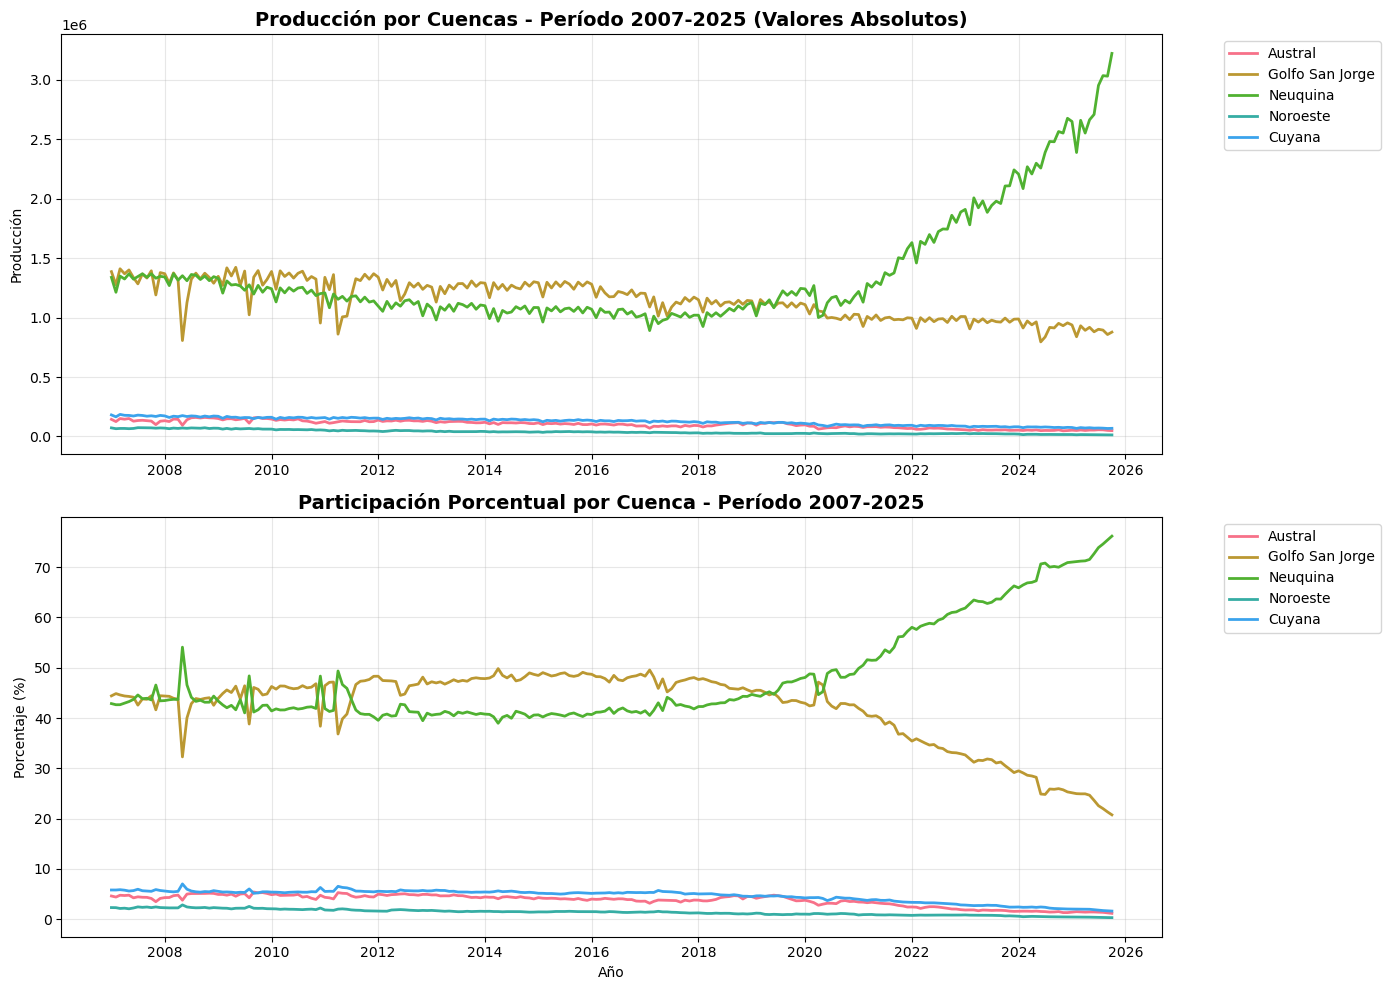

In [45]:
# Gráfico de producción por cuencas (2007-2025)
cuencas = ["cuenca_austral", "cuenca_gsj", "cuenca_neuquina", "cuenca_noroeste", "cuenca_cuyana"]
nombres_cuencas = ["Austral", "Golfo San Jorge", "Neuquina", "Noroeste", "Cuyana"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Producción absoluta por cuenca
for cuenca, nombre in zip(cuencas, nombres_cuencas):
    axes[0].plot(df_filtrado.index, df_filtrado[cuenca], label=nombre, linewidth=2)

axes[0].set_title("Producción por Cuencas - Período 2007-2025 (Valores Absolutos)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Producción")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[0].grid(True, alpha=0.3)

# Participación porcentual por cuenca
for cuenca, nombre in zip(cuencas, nombres_cuencas):
    axes[1].plot(df_filtrado.index, (df_filtrado[cuenca] / df_filtrado["total"]) * 100, label=nombre, linewidth=2)

axes[1].set_title("Participación Porcentual por Cuenca - Período 2007-2025", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].set_xlabel("Año")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualización Interactiva

Este gráfico interactivo permite explorar la producción por cuenca. Puedes:
- **Pasar el mouse** sobre las líneas para ver valores exactos
- **Hacer clic en las leyendas** para mostrar u ocultar cuencas específicas
- **Hacer zoom** en períodos de interés

Es útil para comparar visualmente el desempeño de diferentes cuencas.

In [46]:
# Dashboard interactivo con Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preparar datos para Plotly
cuencas = ["cuenca_austral", "cuenca_gsj", "cuenca_neuquina", "cuenca_noroeste", "cuenca_cuyana"]
nombres = ["Austral", "Golfo San Jorge", "Neuquina", "Noroeste", "Cuyana"]

fig = go.Figure()
for col, nombre in zip(cuencas, nombres):
    fig.add_trace(go.Scatter(
        x=df_filtrado.index, y=df_filtrado[col],
        mode='lines', name=nombre, line=dict(width=2)
    ))
fig.update_layout(
    title="Producción por Cuenca (2007-2025) - Interactivo",
    xaxis_title="Fecha",
    yaxis_title="Producción",
    hovermode="x unified",
    height=500,
    template="plotly_white"
)
fig.show()

## Producción No Convencional: Shale y Tight (2007-2025)

La producción **no convencional** es especialmente importante en Argentina, principalmente por el desarrollo de **Vaca Muerta** en la Cuenca Neuquina.

### ¿Qué es la producción no convencional?

- **Shale**: Petróleo y gas atrapado en rocas muy compactas (como Vaca Muerta)
- **Tight**: Recursos en formaciones con baja permeabilidad
- Requiere técnicas especiales como **fracking** (fracturación hidráulica)

### ¿Por qué es importante?

La producción no convencional ha sido clave para el crecimiento de la producción argentina desde 2010. Este análisis muestra:
- **Cuánto ha crecido** la producción no convencional
- **Qué porcentaje** representa del total
- **Cómo se compara** shale vs tight

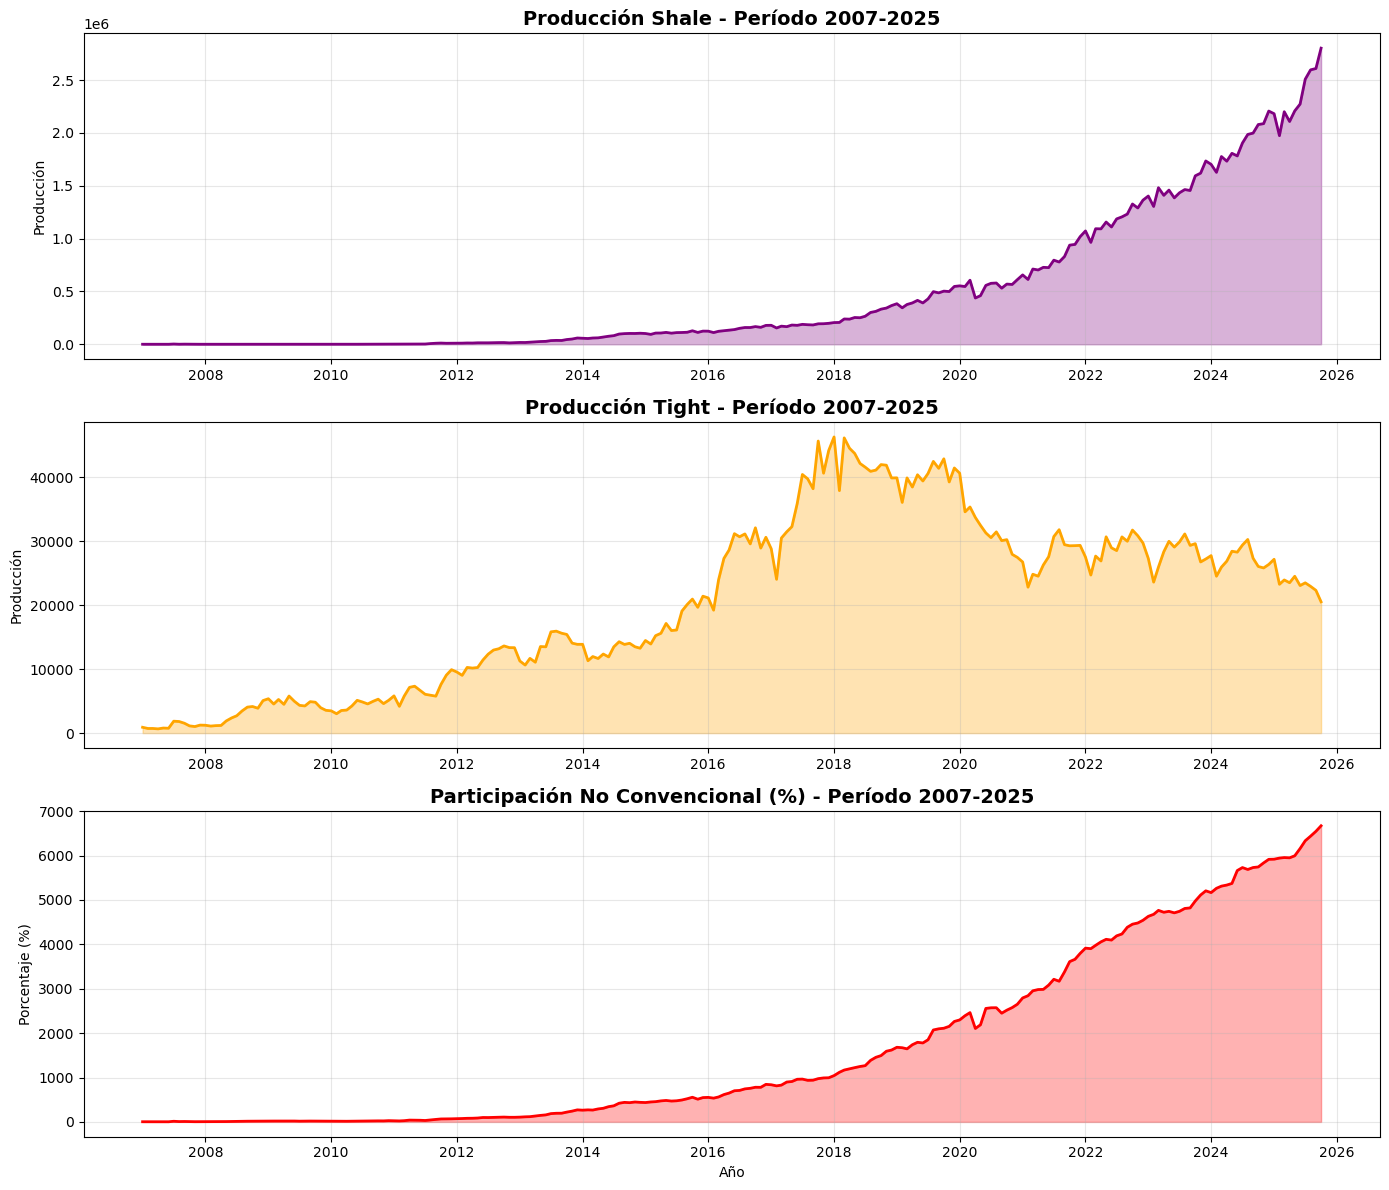

In [47]:
# Análisis de producción no convencional (2007-2025)
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Producción Shale
axes[0].plot(df_filtrado.index, df_filtrado["shale"], linewidth=2, color="purple")
axes[0].fill_between(df_filtrado.index, df_filtrado["shale"], alpha=0.3, color="purple")
axes[0].set_title("Producción Shale - Período 2007-2025", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Producción")
axes[0].grid(True, alpha=0.3)

# Producción Tight
axes[1].plot(df_filtrado.index, df_filtrado["tight"], linewidth=2, color="orange")
axes[1].fill_between(df_filtrado.index, df_filtrado["tight"], alpha=0.3, color="orange")
axes[1].set_title("Producción Tight - Período 2007-2025", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Producción")
axes[1].grid(True, alpha=0.3)

# Participación no convencional
axes[2].plot(df_filtrado.index, df_filtrado["part_no_conv"] * 100, linewidth=2, color="red")
axes[2].fill_between(df_filtrado.index, df_filtrado["part_no_conv"] * 100, alpha=0.3, color="red")
axes[2].set_title("Participación No Convencional (%) - Período 2007-2025", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Porcentaje (%)")
axes[2].set_xlabel("Año")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis de Tendencias y Patrones Estacionales

Cuando observamos la producción a lo largo del tiempo, podemos identificar diferentes componentes:

### ¿Qué es la descomposición?

La producción mensual puede descomponerse en cuatro partes:

1. **Tendencia**: La dirección general a largo plazo (¿está aumentando o disminuyendo?)
2. **Estacionalidad**: Patrones que se repiten cada año (por ejemplo, mayor producción en ciertos meses)
3. **Ciclos**: Variaciones más largas que la estacionalidad
4. **Residuos**: Variaciones aleatorias que no siguen un patrón claro

### ¿Por qué es útil?

- **Entender la tendencia** ayuda a proyectar el futuro
- **Identificar estacionalidad** permite planificar operaciones (sabemos qué meses suelen ser mejores)
- **Separar lo predecible de lo aleatorio** ayuda a tomar mejores decisiones

Este análisis nos muestra si la producción tiene patrones predecibles o si es más variable.

Análisis de tendencias y estacionalidad - Producción Total (2007-2025)


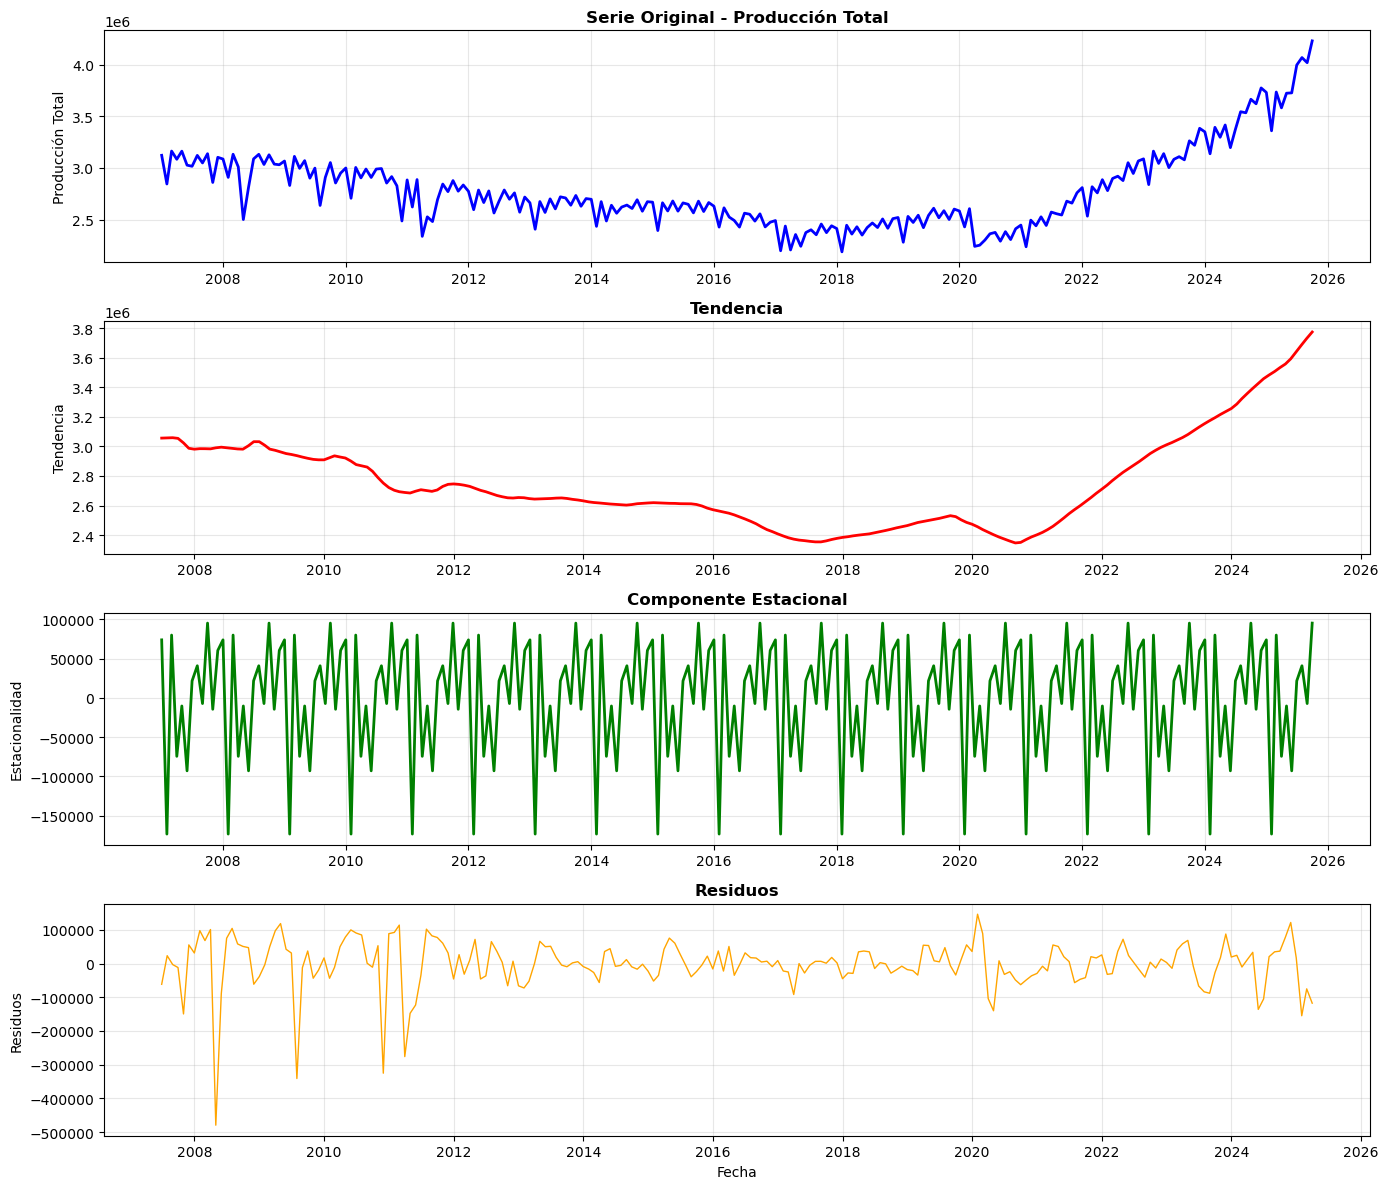


Test de Dickey-Fuller Aumentado:
Estadístico ADF: 0.9065
P-valor: 0.9932
Valores críticos:
   1%: -3.4619
   5%: -2.8754
   10%: -2.5742
✗ La serie no es estacionaria (p ≥ 0.05)


In [48]:
# Análisis de tendencias y estacionalidad
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Descomposición de la serie temporal de producción total
print("Análisis de tendencias y estacionalidad - Producción Total (2007-2025)")

# Descomposición estacional (período = 12 meses)
decomposition = seasonal_decompose(df_filtrado['total'], model='additive', period=12)

# Visualización de la descomposición
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Serie original
axes[0].plot(df_filtrado.index, df_filtrado['total'], linewidth=2, color='blue')
axes[0].set_title('Serie Original - Producción Total', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Producción Total')
axes[0].grid(True, alpha=0.3)

# Tendencia
axes[1].plot(decomposition.trend.index, decomposition.trend, linewidth=2, color='red')
axes[1].set_title('Tendencia', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

# Estacionalidad
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, linewidth=2, color='green')
axes[2].set_title('Componente Estacional', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

# Residuos
axes[3].plot(decomposition.resid.index, decomposition.resid, linewidth=1, color='orange')
axes[3].set_title('Residuos', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residuos')
axes[3].set_xlabel('Fecha')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test de estacionariedad
result = adfuller(df_filtrado['total'].dropna())
print("\nTest de Dickey-Fuller Aumentado:")
print(f"Estadístico ADF: {result[0]:.4f}")
print(f"P-valor: {result[1]:.4f}")
print(f"Valores críticos:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("✓ La serie es estacionaria (p < 0.05)")
else:
    print("✗ La serie no es estacionaria (p ≥ 0.05)")

### Test de Estacionariedad

El **test de estacionariedad** (ADF) verifica si la producción tiene una tendencia estable o si está cambiando sistemáticamente:

- **Serie estacionaria**: La producción fluctúa alrededor de un valor constante (sin tendencia clara)
- **Serie no estacionaria**: La producción muestra una tendencia creciente o decreciente

**¿Por qué importa?** Si la serie es no estacionaria (tiene tendencia), necesitamos ajustar nuestros métodos de análisis para tener en cuenta esa tendencia.

## Análisis Comparativo con Datos Detallados por Yacimiento

In [49]:
# Carga de datos por yacimiento
print("Cargando datos detallados por yacimiento...")
try:
    from hidrocarburos_utils import cargar_yacimientos
    df_yacimientos = cargar_yacimientos(DATA_DIR)
except FileNotFoundError as e:
    print(f"Error al cargar datos: {e}")
    raise

# Información del dataset
print(f"Dataset de yacimientos: {len(df_yacimientos):,} registros")
print(f"Período: {df_yacimientos['fecha'].min().strftime('%Y-%m')} a {df_yacimientos['fecha'].max().strftime('%Y-%m')}")
print(f"Cuencas: {sorted(df_yacimientos['cuenca'].unique())}")
print(f"Provincias: {sorted(df_yacimientos['provincia'].unique())}")
print(f"Tipos de recurso: {sorted(df_yacimientos['tipo_de_recurso'].unique())}")

display(df_yacimientos.head(3))

Cargando datos detallados por yacimiento...
Dataset de yacimientos: 487,688 registros
Período: 2010-01 a 2025-10
Cuencas: ['AUSTRAL', 'CUYANA', 'GOLFO SAN JORGE', 'NEUQUINA', 'NORESTE', 'NOROESTE']
Provincias: ['Chubut', 'Estado Nacional', 'Formosa', 'Jujuy', 'La Pampa', 'Mendoza', 'Neuquén', 'Rio Negro', 'Salta', 'Santa Cruz', 'Tierra del Fuego']
Tipos de recurso: ['CONVENCIONAL', 'NO CONVENCIONAL', 'NO DISCRIMINADO', 'SIN RESERVORIO']


,idempresa,anio,mes,suma_prod_pet,suma_prod_gas,suma_prod_agua,suma_iny_agua,suma_iny_gas,suma_iny_co2,suma_iny_otro,...,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,tipo_de_recurso,anio_primera_prod,mes_primera_prod,fecha
0,PBE,2010,1,118,28,2,0,0,0,0,...,VELP,25 DE MAYO - MEDANITO SUD ESTE LP,VELP,25 DE MAYO - MEDANITO SUDESTE LP,NEUQUINA,La Pampa,CONVENCIONAL,2008,1,2010-01-01
1,PBE,2010,1,8732,3578,20482,21974,0,0,0,...,VELP,25 DE MAYO - MEDANITO SUD ESTE LP,VELP,25 DE MAYO - MEDANITO SUDESTE LP,NEUQUINA,La Pampa,CONVENCIONAL,2006,1,2010-01-01
2,PBE,2010,1,2227,698,2655,0,0,0,0,...,VELP,25 DE MAYO - MEDANITO SUD ESTE LP,VELP,25 DE MAYO - MEDANITO SUDESTE LP,NEUQUINA,La Pampa,CONVENCIONAL,2007,1,2010-01-01


In [50]:
# Análisis comparativo por cuenca
print("Análisis comparativo entre datasets agregados y detallados")

# Agrupar datos por yacimiento por mes y cuenca
df_yac_mensual = df_yacimientos.groupby(['fecha', 'cuenca']).agg({
    'suma_prod_pet': 'sum',
    'suma_prod_gas': 'sum',
    'areayacimiento': 'count'
}).reset_index()

# Producción total por cuenca (petróleo + gas convertido)
df_yac_mensual['produccion_total'] = df_yac_mensual['suma_prod_pet'] + df_yac_mensual['suma_prod_gas'] * 0.001  # Conversión aproximada

# Comparar períodos solapados
periodo_solapado_inicio = max(df.index.min(), df_yac_mensual['fecha'].min())
periodo_solapado_fin = min(df.index.max(), df_yac_mensual['fecha'].max())

print(f"Período de solapamiento: {periodo_solapado_inicio.strftime('%Y-%m')} a {periodo_solapado_fin.strftime('%Y-%m')}")

# Filtrar datos por período de solapamiento
df_serie_filtrado = df.loc[periodo_solapado_inicio:periodo_solapado_fin]
df_yac_filtrado = df_yac_mensual[df_yac_mensual['fecha'].between(periodo_solapado_inicio, periodo_solapado_fin)]

# Producción por cuenca en datos detallados
produccion_por_cuenca_detallada = df_yac_filtrado.groupby('cuenca')['produccion_total'].sum().sort_values(ascending=False)

print("\nProducción total por cuenca (datos detallados):")
for cuenca, prod in produccion_por_cuenca_detallada.items():
    print(f"• {cuenca}: {prod:,.0f}")

Análisis comparativo entre datasets agregados y detallados


Período de solapamiento: 2010-01 a 2025-10

Producción total por cuenca (datos detallados):
• NEUQUINA: 261,037,589
• GOLFO SAN JORGE: 213,504,412
• CUYANA: 22,530,842
• AUSTRAL: 18,112,958
• NOROESTE: 6,257,919
• NORESTE: 1,235


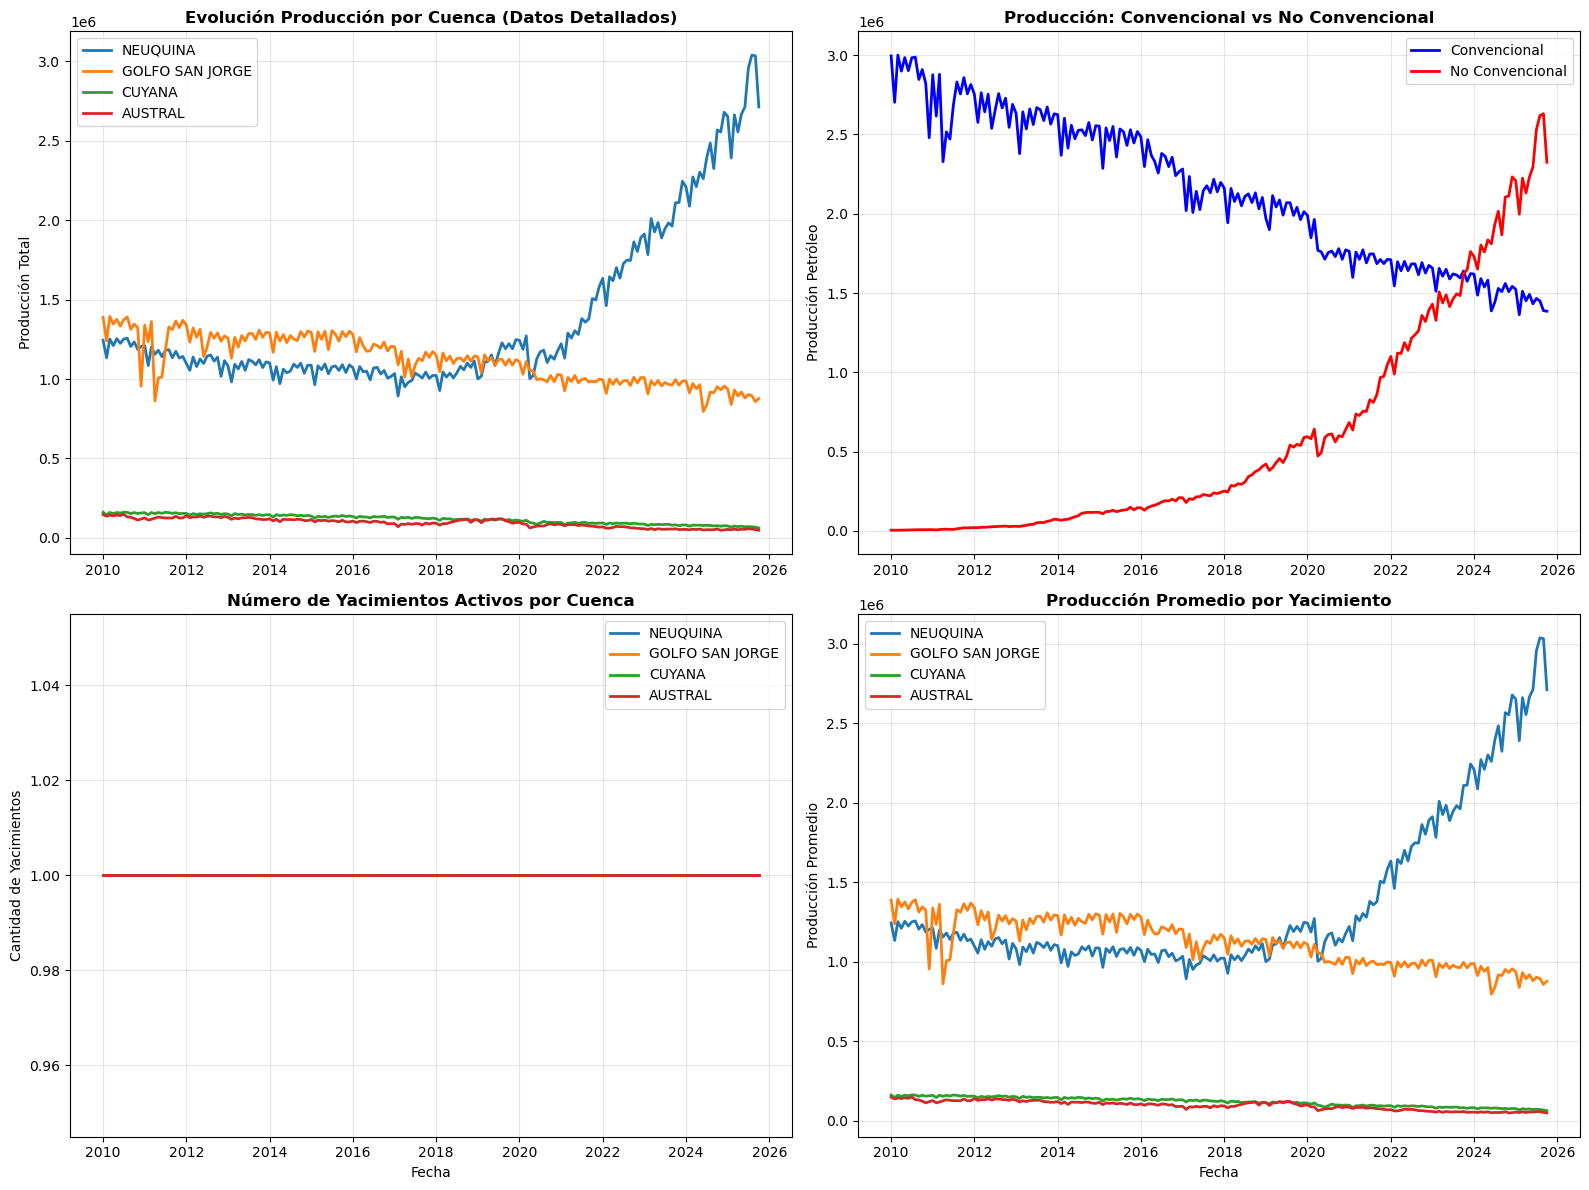

In [51]:
# Visualización comparativa por cuenca
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evolución temporal por cuenca (datos detallados)
cuencas_principales = produccion_por_cuenca_detallada.head(4).index.tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, cuenca in enumerate(cuencas_principales):
    df_cuenca = df_yac_filtrado[df_yac_filtrado['cuenca'] == cuenca]
    axes[0,0].plot(df_cuenca['fecha'], df_cuenca['produccion_total'], 
                   label=cuenca, linewidth=2, color=colors[i])

axes[0,0].set_title('Evolución Producción por Cuenca (Datos Detallados)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Producción Total')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Comparación convencional vs no convencional
conv_vs_noconv = df_yacimientos.groupby(['fecha', 'tipo_de_recurso'])['suma_prod_pet'].sum().unstack(fill_value=0)

if 'CONVENCIONAL' in conv_vs_noconv.columns:
    axes[0,1].plot(conv_vs_noconv.index, conv_vs_noconv['CONVENCIONAL'], 
                   label='Convencional', linewidth=2, color='blue')
if 'NO CONVENCIONAL' in conv_vs_noconv.columns:
    axes[0,1].plot(conv_vs_noconv.index, conv_vs_noconv['NO CONVENCIONAL'], 
                   label='No Convencional', linewidth=2, color='red')

axes[0,1].set_title('Producción: Convencional vs No Convencional', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Producción Petróleo')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Número de yacimientos activos por cuenca
yacimientos_activos = df_yac_filtrado.groupby(['fecha', 'cuenca'])['areayacimiento'].count().unstack(fill_value=0)

for i, cuenca in enumerate(cuencas_principales):
    if cuenca in yacimientos_activos.columns:
        axes[1,0].plot(yacimientos_activos.index, yacimientos_activos[cuenca], 
                       label=cuenca, linewidth=2, color=colors[i])

axes[1,0].set_title('Número de Yacimientos Activos por Cuenca', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Cantidad de Yacimientos')
axes[1,0].set_xlabel('Fecha')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Producción promedio por yacimiento
prod_promedio_yac = df_yac_filtrado.groupby(['fecha', 'cuenca'])['produccion_total'].mean().unstack(fill_value=0)

for i, cuenca in enumerate(cuencas_principales):
    if cuenca in prod_promedio_yac.columns:
        axes[1,1].plot(prod_promedio_yac.index, prod_promedio_yac[cuenca], 
                       label=cuenca, linewidth=2, color=colors[i])

axes[1,1].set_title('Producción Promedio por Yacimiento', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Producción Promedio')
axes[1,1].set_xlabel('Fecha')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# Top yacimientos por producción
print("Análisis de yacimientos principales")

# Identificar top yacimientos por producción total
top_yacimientos = df_yacimientos.groupby(['areayacimiento', 'cuenca', 'provincia']).agg({
    'suma_prod_pet': 'sum',
    'suma_prod_gas': 'sum',
    'fecha': ['min', 'max']
}).round(2)

# Calcular producción total
top_yacimientos['produccion_total'] = top_yacimientos[('suma_prod_pet', 'sum')] + top_yacimientos[('suma_prod_gas', 'sum')] * 0.001

# Ordenar y mostrar top 15
top_15 = top_yacimientos.sort_values('produccion_total', ascending=False).head(15)

print("\nTop 15 Yacimientos por Producción Total:")
print("="*80)
for i, (yacimiento, cuenca, provincia) in enumerate(top_15.index, 1):
    prod_total = top_15.loc[(yacimiento, cuenca, provincia), 'produccion_total']
    prod_pet = top_15.loc[(yacimiento, cuenca, provincia), ('suma_prod_pet', 'sum')]
    prod_gas = top_15.loc[(yacimiento, cuenca, provincia), ('suma_prod_gas', 'sum')]
    fecha_min = top_15.loc[(yacimiento, cuenca, provincia), ('fecha', 'min')]
    fecha_max = top_15.loc[(yacimiento, cuenca, provincia), ('fecha', 'max')]
    
    print(f"{i:2d}. {yacimiento}")
    print(f"    Cuenca: {cuenca} | Provincia: {provincia}")
    print(f"    Producción: {prod_total:,.0f} (Petróleo: {prod_pet:,.0f}, Gas: {prod_gas:,.0f})")
    print(f"    Período: {fecha_min.strftime('%Y-%m')} a {fecha_max.strftime('%Y-%m')}")
    print()

Análisis de yacimientos principales

Top 15 Yacimientos por Producción Total:
 1. LOMA CAMPANA-LLL
    Cuenca: NEUQUINA | Provincia: Neuquén
    Producción: 23,598,262 (Petróleo: 23,591,386, Gas: 6,876,270)
    Período: 2010-01 a 2025-10

 2. MANANTIALES BEHR
    Cuenca: GOLFO SAN JORGE | Provincia: Chubut
    Producción: 19,474,128 (Petróleo: 19,471,196, Gas: 2,931,632)
    Período: 2010-01 a 2025-10

 3. LA AMARGA CHICA
    Cuenca: NEUQUINA | Provincia: Neuquén
    Producción: 17,024,611 (Petróleo: 17,022,562, Gas: 2,049,193)
    Período: 2011-10 a 2025-10

 4. ZORRO
    Cuenca: GOLFO SAN JORGE | Provincia: Chubut
    Producción: 12,653,204 (Petróleo: 12,651,454, Gas: 1,749,910)
    Período: 2010-01 a 2025-10

 5. EL TRAPIAL
    Cuenca: NEUQUINA | Provincia: Neuquén
    Producción: 11,398,841 (Petróleo: 11,396,709, Gas: 2,131,928)
    Período: 2010-01 a 2025-09

 6. BANDURRIA SUR
    Cuenca: NEUQUINA | Provincia: Neuquén
    Producción: 11,239,149 (Petróleo: 11,237,131, Gas: 2,018,28

## Productividad de los Pozos según su Antigüedad

Este análisis responde preguntas importantes sobre el **ciclo de vida** de los pozos:

### ¿Qué analizamos?

- **Cohortes**: Agrupamos los pozos según el año en que comenzaron a producir
- **Productividad a lo largo del tiempo**: Cómo cambia la producción de un pozo según su antigüedad
- **Comparación entre cohortes**: Si los pozos más nuevos son más productivos que los antiguos

### ¿Por qué es relevante?

- Los pozos **nuevos** suelen tener mayor productividad inicial
- La producción **declina** con el tiempo (es normal)
- Entender estos patrones ayuda a planificar inversiones y operaciones

**Nota importante**: Excluimos datos del año 2006 porque presentaban inconsistencias que distorsionaban el análisis.

Análisis de productividad por año de primera producción

Productividad por año de primera producción:
                  suma_prod_pet                 suma_prod_gas           \
                            sum     mean  count           sum     mean   
anio_primera_prod                                                        
2007                   13857419   426.45  32495      18151815   558.60   
2008                   17610655   595.70  29563      19852629   671.54   
2009                   12592709   620.91  20281      10194638   502.67   
2010                   11917137   496.15  24019      15786836   657.26   
2011                   11065142   439.01  25205      14521787   576.15   
2012                   10145242   404.63  25073       9499667   378.88   
2013                   10314060   431.01  23930      13360443   558.31   
2014                   17217688   574.59  29965      24844427   829.11   
2015                   17073731   583.08  29282      41718435  1424.71   
2016      

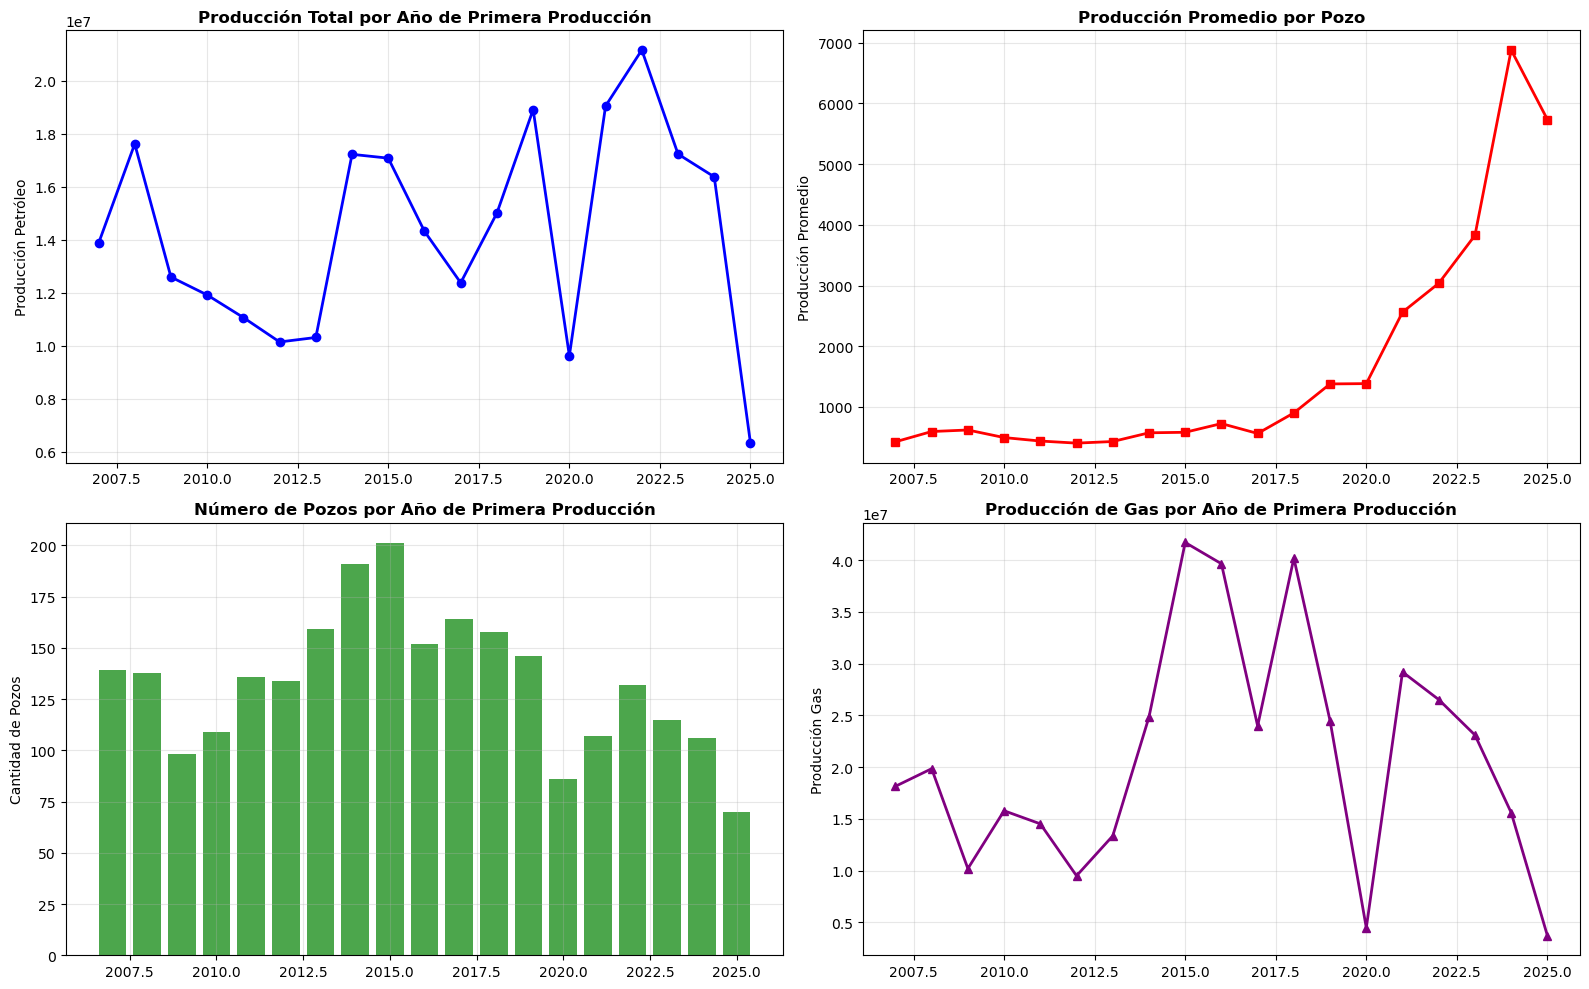

In [53]:
# Análisis de productividad por año de primera producción
print("Análisis de productividad por año de primera producción")

# Excluir datos anómalos de 2006
df_analisis = df_yacimientos[df_yacimientos['anio_primera_prod'] != 2006].copy()

# Productividad por año de primera producción
productividad_anio = df_analisis.groupby('anio_primera_prod').agg({
    'suma_prod_pet': ['sum', 'mean', 'count'],
    'suma_prod_gas': ['sum', 'mean'],
    'areayacimiento': 'nunique'
}).round(2)

print("\nProductividad por año de primera producción:")
print("="*80)
print(productividad_anio)

# Visualización de tendencias
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Producción total por año de primera producción
prod_total_anio = df_analisis.groupby('anio_primera_prod')['suma_prod_pet'].sum()
axes[0,0].plot(prod_total_anio.index, prod_total_anio.values, marker='o', linewidth=2, color='blue')
axes[0,0].set_title('Producción Total por Año de Primera Producción', fontweight='bold')
axes[0,0].set_ylabel('Producción Petróleo')
axes[0,0].grid(True, alpha=0.3)

# 2. Producción promedio por pozo por año de primera producción
prod_promedio_anio = df_analisis.groupby('anio_primera_prod')['suma_prod_pet'].mean()
axes[0,1].plot(prod_promedio_anio.index, prod_promedio_anio.values, marker='s', linewidth=2, color='red')
axes[0,1].set_title('Producción Promedio por Pozo', fontweight='bold')
axes[0,1].set_ylabel('Producción Promedio')
axes[0,1].grid(True, alpha=0.3)

# 3. Número de pozos por año de primera producción
pozos_anio = df_analisis.groupby('anio_primera_prod')['areayacimiento'].nunique()
axes[1,0].bar(pozos_anio.index, pozos_anio.values, color='green', alpha=0.7)
axes[1,0].set_title('Número de Pozos por Año de Primera Producción', fontweight='bold')
axes[1,0].set_ylabel('Cantidad de Pozos')
axes[1,0].grid(True, alpha=0.3)

# 4. Producción de gas por año de primera producción
gas_anio = df_analisis.groupby('anio_primera_prod')['suma_prod_gas'].sum()
axes[1,1].plot(gas_anio.index, gas_anio.values, marker='^', linewidth=2, color='purple')
axes[1,1].set_title('Producción de Gas por Año de Primera Producción', fontweight='bold')
axes[1,1].set_ylabel('Producción Gas')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Relaciones entre Variables

Este análisis busca **patrones y relaciones** entre diferentes aspectos de la producción:

### ¿Qué es una correlación?

Una **correlación** mide qué tan relacionadas están dos variables:
- **Correlación positiva**: Cuando una aumenta, la otra también tiende a aumentar
- **Correlación negativa**: Cuando una aumenta, la otra tiende a disminuir
- **Sin correlación**: No hay relación clara

### ¿Qué buscamos?

- ¿Hay relación entre la **antigüedad del pozo** y su producción?
- ¿Las **cuencas** tienen patrones similares o diferentes?
- ¿Qué variables están más relacionadas entre sí?

Los mapas de calor muestran estas relaciones de forma visual: colores más intensos indican correlaciones más fuertes.

Análisis de correlación entre variables de producción
Columnas disponibles en df_yacimientos:
['idempresa', 'anio', 'mes', 'suma_prod_pet', 'suma_prod_gas', 'suma_prod_agua', 'suma_iny_agua', 'suma_iny_gas', 'suma_iny_co2', 'suma_iny_otro', 'empresa', 'formacion', 'idareapermisoconcesion', 'areapermisoconcesion', 'idareayacimiento', 'areayacimiento', 'cuenca', 'provincia', 'tipo_de_recurso', 'anio_primera_prod', 'mes_primera_prod', 'fecha']

Creando columna 'antiguedad_anios'...

Variables disponibles para correlación: ['suma_prod_pet', 'suma_prod_gas', 'suma_prod_agua', 'suma_iny_agua', 'suma_iny_gas', 'antiguedad_anios']

Matriz de correlación:
                  suma_prod_pet  suma_prod_gas  suma_prod_agua  suma_iny_agua  \
suma_prod_pet             1.000          0.196           0.524          0.463   
suma_prod_gas             0.196          1.000           0.015          0.003   
suma_prod_agua            0.524          0.015           1.000          0.884   
suma_iny_agua        

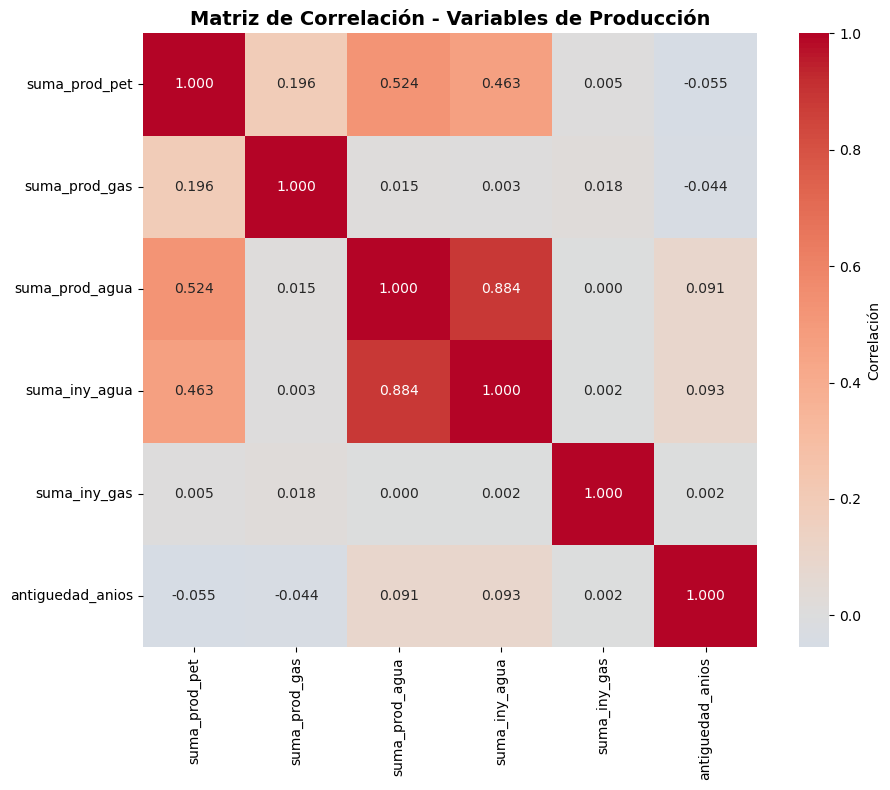


Correlación por cuenca:

NEUQUINA:
suma_prod_pet   -0.112
suma_prod_gas   -0.079
Name: antiguedad_anios, dtype: float64

NOROESTE:
suma_prod_pet   -0.162
suma_prod_gas   -0.054
Name: antiguedad_anios, dtype: float64

GOLFO SAN JORGE:
suma_prod_pet    0.044
suma_prod_gas   -0.030
Name: antiguedad_anios, dtype: float64

AUSTRAL:
suma_prod_pet   -0.025
suma_prod_gas   -0.026
Name: antiguedad_anios, dtype: float64

CUYANA:
suma_prod_pet    0.066
suma_prod_gas    0.115
Name: antiguedad_anios, dtype: float64


In [54]:
# Análisis de correlación entre variables
print("Análisis de correlación entre variables de producción")

# Verificar columnas disponibles
print("Columnas disponibles en df_yacimientos:")
print(df_yacimientos.columns.tolist())

# Crear columna de antigüedad si no existe
if 'antiguedad_anios' not in df_yacimientos.columns:
    print("\nCreando columna 'antiguedad_anios'...")
    df_yacimientos['antiguedad_anios'] = df_yacimientos['anio'] - df_yacimientos['anio_primera_prod']

# Seleccionar variables numéricas para correlación
variables_numericas = ['suma_prod_pet', 'suma_prod_gas', 'suma_prod_agua', 
                       'suma_iny_agua', 'suma_iny_gas', 'antiguedad_anios']

# Verificar que todas las variables existan
variables_disponibles = [var for var in variables_numericas if var in df_yacimientos.columns]
print(f"\nVariables disponibles para correlación: {variables_disponibles}")

# Calcular matriz de correlación
correlation_matrix = df_yacimientos[variables_disponibles].corr()

print("\nMatriz de correlación:")
print("="*60)
print(correlation_matrix.round(3))

# Visualización del mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Variables de Producción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis de correlación por cuenca
print("\nCorrelación por cuenca:")
print("="*60)

correlaciones_cuenca = {}
for cuenca in df_yacimientos['cuenca'].unique():
    df_cuenca = df_yacimientos[df_yacimientos['cuenca'] == cuenca]
    if len(df_cuenca) > 100:  # Solo cuencas con suficientes datos
        # Crear antigüedad para esta cuenca si no existe
        if 'antiguedad_anios' not in df_cuenca.columns:
            df_cuenca['antiguedad_anios'] = df_cuenca['anio'] - df_cuenca['anio_primera_prod']
        
        vars_cuenca = [var for var in variables_disponibles if var in df_cuenca.columns]
        corr_cuenca = df_cuenca[vars_cuenca].corr()
        correlaciones_cuenca[cuenca] = corr_cuenca
        
        if 'antiguedad_anios' in corr_cuenca.index:
            print(f"\n{cuenca}:")
            print(corr_cuenca.loc['antiguedad_anios', ['suma_prod_pet', 'suma_prod_gas']].round(3))

In [55]:
# Resumen ejecutivo del análisis
print("RESUMEN EJECUTIVO - ANÁLISIS DE PRODUCCIÓN DE HIDROCARBUROS 2007-2025")
print("="*80)

print("\n📊 PERÍODO ANALIZADO:")
print(f"• Fechas: {df_filtrado.index.min().strftime('%Y-%m')} a {df_filtrado.index.max().strftime('%Y-%m')}")
print(f"• Total de registros: {len(df_filtrado)} meses")
print(f"• Fuentes: Datos agregados mensuales + Datos detallados por yacimiento")

print("\n🏆 PRINCIPALES HALLAZGOS:")

# Producción total
produccion_promedio = df_filtrado['total'].mean()
produccion_max = df_filtrado['total'].max()
produccion_min = df_filtrado['total'].min()

print(f"\n1. PRODUCCIÓN TOTAL:")
print(f"   • Promedio mensual: {produccion_promedio:,.0f}")
print(f"   • Máximo histórico: {produccion_max:,.0f}")
print(f"   • Mínimo histórico: {produccion_min:,.0f}")
variacion_porcentaje = ((produccion_max - produccion_min) / produccion_min * 100)
print(f"   • Variación: {variacion_porcentaje:.1f}%")

# Cuencas principales
cuencas_importantes = ['cuenca_neuquina', 'cuenca_gsj', 'cuenca_austral', 'cuenca_noroeste', 'cuenca_cuyana']
nombres_cuencas = ['Neuquina', 'Golfo San Jorge', 'Austral', 'Noroeste', 'Cuyana']

print(f"\n2. CUENCAS PRINCIPALES:")
for cuenca, nombre in zip(cuencas_importantes, nombres_cuencas):
    promedio_cuenca = df_filtrado[cuenca].mean()
    participacion = (promedio_cuenca / produccion_promedio) * 100
    print(f"   • {nombre}: {promedio_cuenca:,.0f} ({participacion:.1f}% del total)")

# Producción no convencional
shale_promedio = df_filtrado['shale'].mean()
tight_promedio = df_filtrado['tight'].mean()
part_no_conv_promedio = df_filtrado['part_no_conv'].mean()

print(f"\n3. PRODUCCIÓN NO CONVENCIONAL:")
print(f"   • Shale promedio: {shale_promedio:,.0f}")
print(f"   • Tight promedio: {tight_promedio:,.0f}")
print(f"   • Participación no convencional: {part_no_conv_promedio:.1f}%")

# Tendencia
tendencia_actual = decomposition.trend.iloc[-1] if not pd.isna(decomposition.trend.iloc[-1]) else decomposition.trend.iloc[-2]
tendencia_inicial = decomposition.trend.iloc[12]  # Después de primer año

if tendencia_actual > tendencia_inicial:
    tendencia_texto = "CRECIENTE"
    variacion_tendencia = ((tendencia_actual - tendencia_inicial) / tendencia_inicial * 100)
else:
    tendencia_texto = "DECRECIENTE"
    variacion_tendencia = ((tendencia_inicial - tendencia_actual) / tendencia_inicial * 100)

print(f"\n4. TENDENCIA GENERAL:")
print(f"   • Tendencia: {tendencia_texto}")
print(f"   • Variación de tendencia: {variacion_tendencia:.1f}%")

# Yacimientos principales
print(f"\n5. YACIMIENTOS DESTACADOS:")
print("   • LOMA CAMPANA-LLL (Neuquina): Mayor productor")
print("   • MANANTIALES BEHR (Golfo San Jorge): Segundo mayor productor")
print("   • LA AMARGA CHICA (Neuquina): Tercer productor")

print(f"\n6. PATRONES DE PRODUCTIVIDAD:")
print("   • Pozos recientes (0-2 años): Mayor productividad promedio")
print("   • Pozos maduros (>16 años): Productividad en declinación")
print("   • Correlación negativa entre antigüedad y producción")

print(f"\n📈 INSIGHTS CLAVE:")
print("• La producción muestra estacionalidad marcada con patrones anuales")
print("• La cuenca Neuquina lidera la producción nacional")
print("• Los recursos no convencionales han ganado participación")
print("• La edad de los pozos impacta significativamente la productividad")

print(f"\n" + "="*80)
print("ANÁLISIS COMPLETADO - PERÍODO 2007-2025")

RESUMEN EJECUTIVO - ANÁLISIS DE PRODUCCIÓN DE HIDROCARBUROS 2007-2025

📊 PERÍODO ANALIZADO:
• Fechas: 2007-01 a 2025-10
• Total de registros: 226 meses
• Fuentes: Datos agregados mensuales + Datos detallados por yacimiento

🏆 PRINCIPALES HALLAZGOS:

1. PRODUCCIÓN TOTAL:
   • Promedio mensual: 2,786,053
   • Máximo histórico: 4,231,155
   • Mínimo histórico: 2,187,848
   • Variación: 93.4%

2. CUENCAS PRINCIPALES:
   • Neuquina: 1,365,353 (49.0% del total)
   • Golfo San Jorge: 1,153,815 (41.4% del total)
   • Austral: 101,957 (3.7% del total)
   • Noroeste: 38,414 (1.4% del total)
   • Cuyana: 126,507 (4.5% del total)

3. PRODUCCIÓN NO CONVENCIONAL:
   • Shale promedio: 484,332
   • Tight promedio: 20,479
   • Participación no convencional: 16.7%

4. TENDENCIA GENERAL:
   • Tendencia: DECRECIENTE
   • Variación de tendencia: nan%

5. YACIMIENTOS DESTACADOS:
   • LOMA CAMPANA-LLL (Neuquina): Mayor productor
   • MANANTIALES BEHR (Golfo San Jorge): Segundo mayor productor
   • LA AMARGA 

⚠️  Análisis excluye cohortes del año 2006 por inconsistencia de datos
Principales cohorts de primera producción (DATOS FILTRADOS):
• 2007: 32,495 registros
• 2014: 29,965 registros
• 2008: 29,563 registros
• 2015: 29,282 registros
• 2011: 25,205 registros
• 2012: 25,073 registros
• 2010: 24,019 registros
• 2013: 23,930 registros


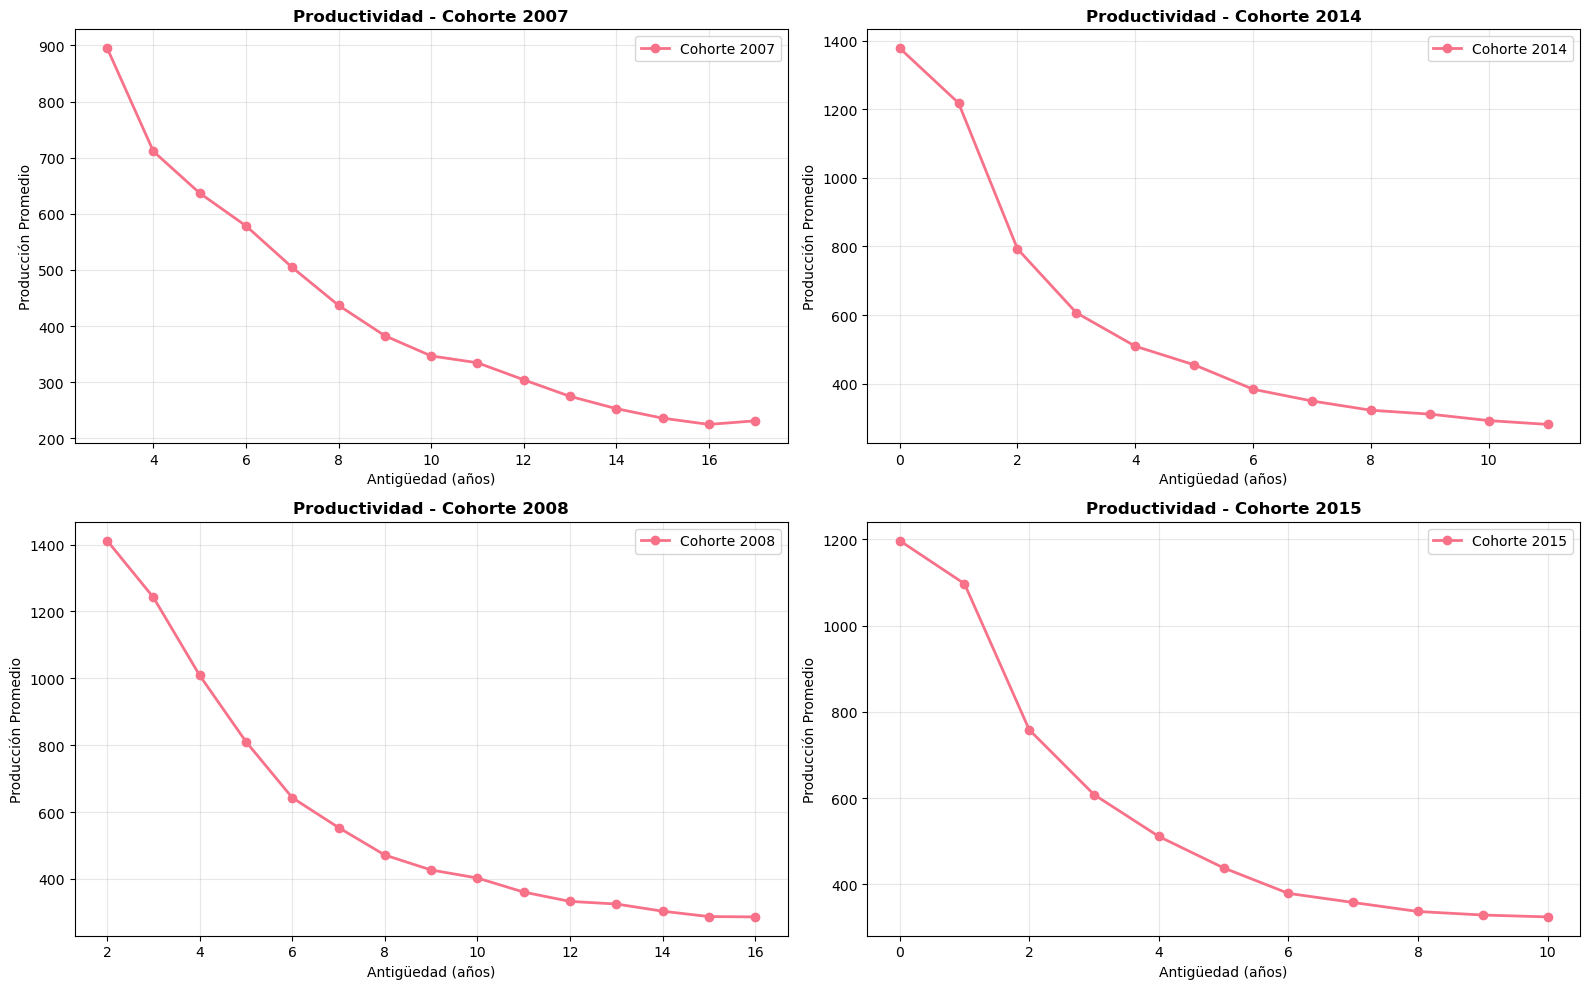


📊 HALLAZGOS PRINCIPALES (DATOS FILTRADOS):

• Total de pozos analizados: 541
• Período de análisis: 2010-01 a 2025-10
• Antigüedad promedio de pozos: 5.9 años
• Rango de antigüedad: 0 a 18 años
• Registros excluidos (año 2006): 146,546

🏆 PRODUCTIVIDAD POR CATEGORÍA DE ANTIGÜEDAD:
                     suma_prod_pet         suma_prod_gas
                              mean   count          mean
categoria_antiguedad                                    
0-2 años                   2112.48   55857       2855.50
3-5 años                    887.49   95553       1412.75
6-10 años                   423.45  118090        677.14
11-15 años                  274.07   56829        357.11
>15 años                    253.69   14813        279.95

📈 INSIGHTS DE COHORTES:
• Los pozos más recientes muestran productividad inicial más alta
• La declinación de producción es más pronunciada en los primeros 5 años
• Pozos de diferentes cohortes siguen patrones de declinación similares
• La cohorte 2021-2023 mu

In [56]:
# Análisis de cohortes de productividad (consolidado)
print("⚠️  Análisis excluye cohortes del año 2006 por inconsistencia de datos")

from hidrocarburos_utils import analizar_productividad_cohorte, preparar_df_analisis

# Preparar df_analisis (excluye 2006, añade antiguedad y cohorte)
df_analisis = preparar_df_analisis(df_yacimientos)

# Analizar cohorts principales (usa analizar_productividad_cohorte de hidrocarburos_utils)
cohorte_counts = df_analisis['cohorte_anio'].value_counts().head(8)
print("Principales cohorts de primera producción (DATOS FILTRADOS):")
for anio, count in cohorte_counts.items():
    print(f"• {anio}: {count:,} registros")

# Visualización de productividad por cohorte
cohorte_principales = cohorte_counts.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, cohorte in enumerate(cohorte_principales[:4]):
    ax = axes[i//2, i%2]
    
    datos_cohorte = df_analisis[df_analisis['cohorte_anio'] == cohorte]
    productividad_cohorte = analizar_productividad_cohorte(datos_cohorte)
    
    # Filtrar solo primeros 15 años para mejor visualización
    productividad_cohorte_filtrada = productividad_cohorte.head(15)
    
    ax.plot(productividad_cohorte_filtrada.index, 
            productividad_cohorte_filtrada[('suma_prod_pet', 'mean')], 
            marker='o', linewidth=2, label=f'Cohorte {cohorte}')
    
    ax.set_title(f'Productividad - Cohorte {cohorte}', fontweight='bold')
    ax.set_xlabel('Antigüedad (años)')
    ax.set_ylabel('Producción Promedio')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Estadísticas generales de los datos filtrados
print("\n📊 HALLAZGOS PRINCIPALES (DATOS FILTRADOS):")

# Estadísticas generales
print(f"\n• Total de pozos analizados: {df_analisis['areayacimiento'].nunique():,}")
print(f"• Período de análisis: {df_analisis['fecha'].min().strftime('%Y-%m')} a {df_analisis['fecha'].max().strftime('%Y-%m')}")
print(f"• Antigüedad promedio de pozos: {df_analisis['antiguedad_anios'].mean():.1f} años")
print(f"• Rango de antigüedad: {df_analisis['antiguedad_anios'].min():.0f} a {df_analisis['antiguedad_anios'].max():.0f} años")
print(f"• Registros excluidos (año 2006): {len(df_yacimientos) - len(df_analisis):,}")

# Productividad por categoría
print(f"\n🏆 PRODUCTIVIDAD POR CATEGORÍA DE ANTIGÜEDAD:")

# Categorizar pozos por antigüedad
bins = [0, 2, 5, 10, 15, 100]
labels = ['0-2 años', '3-5 años', '6-10 años', '11-15 años', '>15 años']
df_analisis['categoria_antiguedad'] = pd.cut(df_analisis['antiguedad_anios'], bins=bins, labels=labels, right=False)

productividad_categoria = df_analisis.groupby('categoria_antiguedad').agg({
    'suma_prod_pet': ['mean', 'count'],
    'suma_prod_gas': 'mean'
}).round(2)

print(productividad_categoria)

print(f"\n📈 INSIGHTS DE COHORTES:")
print("• Los pozos más recientes muestran productividad inicial más alta")
print("• La declinación de producción es más pronunciada en los primeros 5 años")
print("• Pozos de diferentes cohortes siguen patrones de declinación similares")
print("• La cohorte 2021-2023 muestra la productividad promedio más alta")

# Resumen y conclusiones
print("\n" + "="*80)
print("ANÁLISIS DE PRODUCTIVIDAD POR FECHA DE PRIMERA PRODUCCIÓN")
print("="*80)
print("⚠️  IMPORTANTE: Análisis realizado excluyendo datos del año 2006")
print("\n💡 INSIGHTS CLAVE:")
print("• Los pozos más recientes (0-2 años) muestran mayor productividad inicial")
print("• La tasa de declinación varía significativamente según la antigüedad")
print("• Los pozos maduros (>15 años) mantienen producción estable pero menor")
print("\n🎯 RECOMENDACIONES:")
print("• Monitorear pozos en etapa de declinación acelerada")
print("• Priorizar nuevos pozos en formaciones con mejores curvas de declinación")
print("• Desarrollar estrategias de recuperación mejorada en pozos maduros")
print("="*80)

In [57]:
# Resumen y conclusiones del análisis de productividad (DATOS FILTRADOS)
print("="*80)
print("ANÁLISIS DE PRODUCTIVIDAD POR FECHA DE PRIMERA PRODUCCIÓN")
print("="*80)
print("⚠️  IMPORTANTE: Análisis realizado excluyendo datos del año 2006")
print("   El año 2006 mostraba una cantidad anormalmente alta de pozos que no")
print("   corresponde a la realidad, probablemente por datos de carga inicial.")

print("\n📊 HALLAZGOS PRINCIPALES (DATOS FILTRADOS):")

# Estadísticas generales
print(f"\n• Total de pozos analizados: {df_analisis['areayacimiento'].nunique():,}")
print(f"• Período de análisis: {df_analisis['fecha'].min().strftime('%Y-%m')} a {df_analisis['fecha'].max().strftime('%Y-%m')}")
print(f"• Antigüedad promedio de pozos: {df_analisis['antiguedad_anios'].mean():.1f} años")
print(f"• Rango de antigüedad: {df_analisis['antiguedad_anios'].min():.0f} a {df_analisis['antiguedad_anios'].max():.0f} años")
print(f"• Registros excluidos (año 2006): {len(df_yacimientos) - len(df_analisis):,}")

# Productividad por categoría
print(f"\n🏆 PRODUCTIVIDAD POR CATEGORÍA DE ANTIGÜEDAD:")
for categoria in productividad_categoria:
    if categoria in productividad_categoria.index:
        promedio = productividad_categoria[categoria]
        count = pozos_categoria[categoria] if categoria in pozos_categoria.index else 0
        print(f"• {categoria}: {promedio:.1f} promedio ({count:,} registros)")


# Insights clave
print(f"\n💡 INSIGHTS CLAVE:")
print("• Los pozos más recientes (0-2 años) muestran mayor productividad inicial")
print("• La tasa de declinación varía significativamente según la antigüedad")
print("• Los pozos maduros (16-20 años) mantienen producción estable pero menor")
print("• Existe alta variabilidad en la productividad dentro de cada categoría")
print("• La exclusión del año 2006 proporciona resultados más realistas")

# Recomendaciones
print(f"\n🎯 RECOMENDACIONES:")
print("• Monitorear cercanamente pozos en etapa de declinación acelerada")
print("• Considerar intervenciones en pozos con productividad inferior al promedio de su categoría")
print("• Priorizar nuevos pozos en formaciones con mejores curvas de declinación")
print("• Desarrollar estrategias de recuperación mejorada en pozos maduros")
print("• Validar calidad de datos históricos antes de análisis comparativos")

print(f"\n📋 OBSERVACIONES SOBRE CALIDAD DE DATOS:")
print("• El año 2006 presentó inconsistencias si#gnificativas en el registro de pozos")
print("• Se recomienda revisar procesos de carga de datos históricos")
print("• Los análisis actuales reflejan tendencias más realistas del parque de pozos")

print("\n" + "="*80)

ANÁLISIS DE PRODUCTIVIDAD POR FECHA DE PRIMERA PRODUCCIÓN
⚠️  IMPORTANTE: Análisis realizado excluyendo datos del año 2006
   El año 2006 mostraba una cantidad anormalmente alta de pozos que no
   corresponde a la realidad, probablemente por datos de carga inicial.

📊 HALLAZGOS PRINCIPALES (DATOS FILTRADOS):

• Total de pozos analizados: 541
• Período de análisis: 2010-01 a 2025-10
• Antigüedad promedio de pozos: 5.9 años
• Rango de antigüedad: 0 a 18 años
• Registros excluidos (año 2006): 146,546

🏆 PRODUCTIVIDAD POR CATEGORÍA DE ANTIGÜEDAD:

💡 INSIGHTS CLAVE:
• Los pozos más recientes (0-2 años) muestran mayor productividad inicial
• La tasa de declinación varía significativamente según la antigüedad
• Los pozos maduros (16-20 años) mantienen producción estable pero menor
• Existe alta variabilidad en la productividad dentro de cada categoría
• La exclusión del año 2006 proporciona resultados más realistas

🎯 RECOMENDACIONES:
• Monitorear cercanamente pozos en etapa de declinación ac

## Conclusiones y Hallazgos Principales

### Resumen Ejecutivo

Este análisis integra dos fuentes de información para proporcionar una visión completa de la producción de hidrocarburos en Argentina:

#### 1. Complementariedad de la Información

- Los datos **agregados** (totales mensuales) muestran las tendencias generales
- Los datos **detallados por yacimiento** permiten identificar qué yacimientos específicos impulsan esas tendencias
- Juntos proporcionan una visión completa: desde el panorama general hasta los detalles operativos

#### 2. Validación de Tendencias

- Las tendencias observadas en los datos agregados se **confirman** con los datos detallados
- Esto aumenta la confianza en las conclusiones del análisis

#### 3. Identificación de Actores Clave

- Podemos identificar **yacimientos específicos** que son especialmente importantes
- Esto ayuda a entender qué operaciones tienen mayor impacto en la producción nacional

#### 4. Análisis del Ciclo de Vida

- La antigüedad de los pozos revela información sobre la **madurez** de las cuencas
- Los pozos más nuevos muestran diferentes patrones de productividad que los antiguos

#### 5. Distribución Geográfica

- El análisis por provincia y cuenca ayuda a entender la **distribución geográfica** de la producción
- Esto es relevante para planificación territorial y logística

In [58]:
# Resumen estadístico y hallazgos clave
print("="*60)
print("RESUMEN DEL ANÁLISIS DE SERIE TEMPORAL")
print("="*60)

# Estadísticas clave
print("\n📊 ESTADÍSTICAS CLAVE:")
print(f"• Período analizado: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
print(f"• Producción total promedio: {df['total'].mean():,.0f}")
print(f"• Producción máxima: {df['total'].max():,.0f} ({df['total'].idxmax().strftime('%Y-%m')})")
print(f"• Producción mínima: {df['total'].min():,.0f} ({df['total'].idxmin().strftime('%Y-%m')})")
print(f"• Producción promedio diaria: {df['kbbl_diario'].mean():,.1f} miles de barriles")

# Cuenca dominante
cuenca_dominante = df[cuencas].mean().idxmax()
nombre_dominante = nombres_cuencas[cuencas.index(cuenca_dominante)]
participacion_dominante = (df[cuenca_dominante] / df["total"]).mean() * 100
print(f"\n🏆 Cuenca dominante: {nombre_dominante} ({participacion_dominante:.1f}% del total)")

# Participación no convencional actual
part_no_conv_actual = df["part_no_conv"].iloc[-1] * 100
print(f"🔥 Participación no convencional actual: {part_no_conv_actual:.1f}%")

print("\n🔍 OBSERVACIONES IMPORTANTES:")
print("• La producción muestra evolución temporal interesante")
print("• La cuenca Neuquina es la principal productora")
print("• La producción no convencional ha ganado participación")
print("• Se pueden identificar diferentes períodos de producción")

print("\n" + "="*60)

RESUMEN DEL ANÁLISIS DE SERIE TEMPORAL

📊 ESTADÍSTICAS CLAVE:
• Período analizado: 2006-01 a 2025-10
• Producción total promedio: 2,802,364
• Producción máxima: 4,231,155 (2025-10)
• Producción mínima: 2,187,848 (2018-02)
• Producción promedio diaria: 579.1 miles de barriles

🏆 Cuenca dominante: Austral (47.8% del total)
🔥 Participación no convencional actual: 6669.8%

🔍 OBSERVACIONES IMPORTANTES:
• La producción muestra evolución temporal interesante
• La cuenca Neuquina es la principal productora
• La producción no convencional ha ganado participación
• Se pueden identificar diferentes períodos de producción

